In [84]:
# Titanic Survival Prediction

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
df = pd.read_csv('train.csv')

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)

# Feature engineering
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Dr','Col','Major','Rev','Lady','Sir','Capt'], 'Rare')

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamilySize'] == 1).astype(int)

# Drop unnecessary columns
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# Encoding
df = pd.get_dummies(df, columns=['Sex','Embarked','Title'], drop_first=True)

# Split features & target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Ensure no missing values
X = X.fillna(X.median())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Evaluation
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("\nTrain Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

# Cross Validation
scores = cross_val_score(rf_model, X, y, cv=5)
print("\nCV Scores:", scores)
print("Mean CV Score:", scores.mean())

Logistic Accuracy: 0.8100558659217877


Random Forest Accuracy: 0.8212290502793296

Confusion Matrix:
 [[91 14]
 [18 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


Train Accuracy: 0.8497191011235955
Test Accuracy: 0.8212290502793296

CV Scores: [0.83798883 0.82022472 0.8258427  0.79775281 0.85393258]
Mean CV Score: 0.8271483271608814


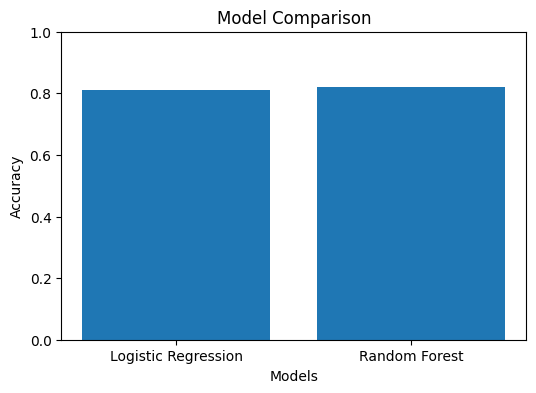

In [88]:
import matplotlib.pyplot as plt

# Models aur accuracy
models = ['Logistic Regression', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

# Graph plot
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()